In [1]:
pip install pandas openpyxl


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# Utilizando o caminho absoluto com 'r' para o Windows encontrar o arquivo
caminho_arquivo = r'C:\Users\mauro.pupim\OneDrive - CantuStore\Documentos\Cursos\FIAP\Tech Challenge - Fase 5\data\BASE DE DADOS PEDE 2024 - DATATHON.xlsx'

# Carregando as bases de dados apontando para o nome de cada aba
df_2022 = pd.read_excel(caminho_arquivo, sheet_name='PEDE2022')
df_2023 = pd.read_excel(caminho_arquivo, sheet_name='PEDE2023')
df_2024 = pd.read_excel(caminho_arquivo, sheet_name='PEDE2024')

# Verificando o tamanho de cada base
print(f"Dimensões 2022: {df_2022.shape}")
print(f"Dimensões 2023: {df_2023.shape}")
print(f"Dimensões 2024: {df_2024.shape}")

Dimensões 2022: (860, 42)
Dimensões 2023: (1014, 48)
Dimensões 2024: (1156, 50)


In [3]:
# Visualizando as colunas de cada base
print("Qtd colunas 2022:", len(df_2022.columns))
print("Colunas 2022:", df_2022.columns.tolist()[:15]) # Mostrando apenas as 15 primeiras para não poluir muito

print("\nQtd colunas 2023:", len(df_2023.columns))
print("Colunas 2023:", df_2023.columns.tolist()[:15])

print("\nQtd colunas 2024:", len(df_2024.columns))
print("Colunas 2024:", df_2024.columns.tolist()[:15])

Qtd colunas 2022: 42
Colunas 2022: ['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf']

Qtd colunas 2023: 48
Colunas 2023: ['RA', 'Fase', 'INDE 2023', 'Pedra 2023', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23']

Qtd colunas 2024: 50
Colunas 2024: ['RA', 'Fase', 'INDE 2024', 'Pedra 2024', 'Turma', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'Pedra 23']


In [4]:
import pandas as pd
import numpy as np

# 1. Definindo as colunas (Sem o IPP em 2022)
cols_2022 = ['RA', 'Fase', 'INDE 22', 'IDA', 'IEG', 'IAA', 'IPS', 'IPV', 'IAN']
cols_2023 = ['RA', 'Fase', 'INDE 2023', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'IAN']
cols_2024 = ['RA', 'Fase', 'INDE 2024', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'IAN']

# 2. Filtrando os DataFrames
df_22_filtrado = df_2022[cols_2022].copy()
df_23_filtrado = df_2023[cols_2023].copy()
df_24_filtrado = df_2024[cols_2024].copy()

# 3. Renomeando as colunas
df_22_filtrado.columns = ['RA', 'Fase_2022', 'INDE_2022', 'IDA_2022', 'IEG_2022', 'IAA_2022', 'IPS_2022', 'IPV_2022', 'IAN_2022']
df_23_filtrado.columns = ['RA', 'Fase_2023', 'INDE_2023', 'IDA_2023', 'IEG_2023', 'IAA_2023', 'IPS_2023', 'IPP_2023', 'IPV_2023', 'IAN_2023']
df_24_filtrado.columns = ['RA', 'Fase_2024', 'INDE_2024', 'IDA_2024', 'IEG_2024', 'IAA_2024', 'IPS_2024', 'IPP_2024', 'IPV_2024', 'IAN_2024']

# Adicionando a coluna IPP_2022 vazia apenas para manter a consistência da base histórica
df_22_filtrado['IPP_2022'] = np.nan

# 4. Unindo os DataFrames (Merge Horizontal)
df_historico = pd.merge(df_22_filtrado, df_23_filtrado, on='RA', how='outer')
df_historico = pd.merge(df_historico, df_24_filtrado, on='RA', how='outer')

# Converter colunas numéricas que possam ter vindo como texto para float
colunas_para_converter = df_historico.columns.drop(['RA', 'Fase_2022', 'Fase_2023', 'Fase_2024'])
for col in colunas_para_converter:
    # O coerce transforma qualquer erro (como texto ou '#N/A') em NaN (nulo)
    df_historico[col] = pd.to_numeric(df_historico[col], errors='coerce')

# 5. FEATURE ENGINEERING: Criando variáveis de evolução
df_historico['Evolucao_INDE_22_23'] = df_historico['INDE_2023'] - df_historico['INDE_2022']
df_historico['Evolucao_IDA_22_23'] = df_historico['IDA_2023'] - df_historico['IDA_2022']

df_historico['Evolucao_INDE_23_24'] = df_historico['INDE_2024'] - df_historico['INDE_2023']
df_historico['Evolucao_IDA_23_24'] = df_historico['IDA_2024'] - df_historico['IDA_2023']

print(f"Tamanho do Dataset Histórico Final: {df_historico.shape}")
df_historico.head()

Tamanho do Dataset Histórico Final: (1661, 32)


,RA,Fase_2022,INDE_2022,IDA_2022,IEG_2022,IAA_2022,IPS_2022,IPV_2022,IAN_2022,IPP_2022,...,IEG_2024,IAA_2024,IPS_2024,IPP_2024,IPV_2024,IAN_2024,Evolucao_INDE_22_23,Evolucao_IDA_22_23,Evolucao_INDE_23_24,Evolucao_IDA_23_24
0,RA-1,7.0,5.783,4.0,4.1,8.3,5.6,7.278,5.0,NaN,...,0.000000,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN
1,RA-10,7.0,5.784,4.1,5.2,8.3,5.0,7.056,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RA-100,4.0,7.618,7.6,7.8,8.8,5.0,7.250,10.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,RA-1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.545455,9.002,6.26,8.125000,7.835,10.0,NaN,NaN,0.448591,0.75
4,RA-1001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.347826,7.502,7.51,7.916667,7.920,5.0,NaN,NaN,-0.319768,-0.05


In [5]:
from sklearn.model_selection import train_test_split

# 1. Criando a Variável Alvo (Target) baseada no IAN de 2024
# 1 = Em Risco/Defasado (IAN < 10), 0 = Sem Risco/Em Fase (IAN == 10)
df_historico['Risco_Defasagem'] = (df_historico['IAN_2024'] < 10).astype(int)

# Como queremos prever 2024, só podemos usar alunos que têm a avaliação de 2024
df_modelagem = df_historico.dropna(subset=['IAN_2024']).copy()

# 2. Selecionando as Features (X) - O que o modelo vai usar para aprender
# Vamos usar os indicadores de 2022, 2023 e a evolução 22-23. 
# ATENÇÃO: Não usamos nada de 2024 aqui, pois 2024 é o "futuro" que queremos prever!
features = [
    'INDE_2022', 'IDA_2022', 'IEG_2022', 'IAA_2022', 'IPS_2022', 'IPV_2022', 'IAN_2022',
    'INDE_2023', 'IDA_2023', 'IEG_2023', 'IAA_2023', 'IPS_2023', 'IPV_2023', 'IAN_2023',
    'Evolucao_INDE_22_23', 'Evolucao_IDA_22_23'
]

X = df_modelagem[features]
y = df_modelagem['Risco_Defasagem']

# 3. Tratamento de Valores Nulos nas Features
# Como alguns alunos entraram só em 2023, eles terão dados nulos em 2022.
# Uma abordagem inicial simples é preencher os nulos com um valor neutro (ex: -1) ou com a mediana.
# Vamos usar -1 para que o modelo entenda que "falta de dado" é um padrão em si (aluno novo).
X = X.fillna(-1)

# 4. Separação em Treino e Teste (80% para o modelo aprender, 20% para testarmos a prova cega)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho da base de Treino: {X_train.shape[0]} alunos")
print(f"Tamanho da base de Teste: {X_test.shape[0]} alunos")
print("\nDistribuição do Risco na base de modelagem (0 = Sem Risco, 1 = Em Risco):")
print(y.value_counts())

Tamanho da base de Treino: 924 alunos
Tamanho da base de Teste: 232 alunos

Distribuição do Risco na base de modelagem (0 = Sem Risco, 1 = Em Risco):
Risco_Defasagem
0    622
1    534
Name: count, dtype: int64


--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.80      0.70      0.74       125
           1       0.69      0.79      0.74       107

    accuracy                           0.74       232
   macro avg       0.74      0.75      0.74       232
weighted avg       0.75      0.74      0.74       232



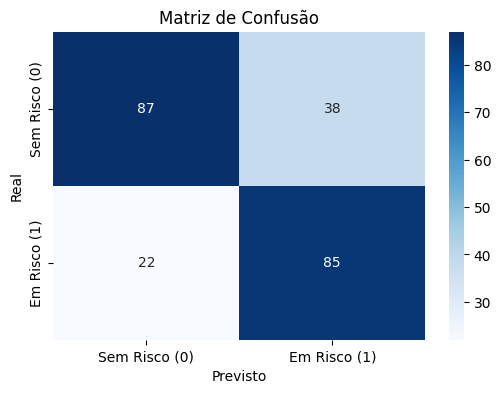

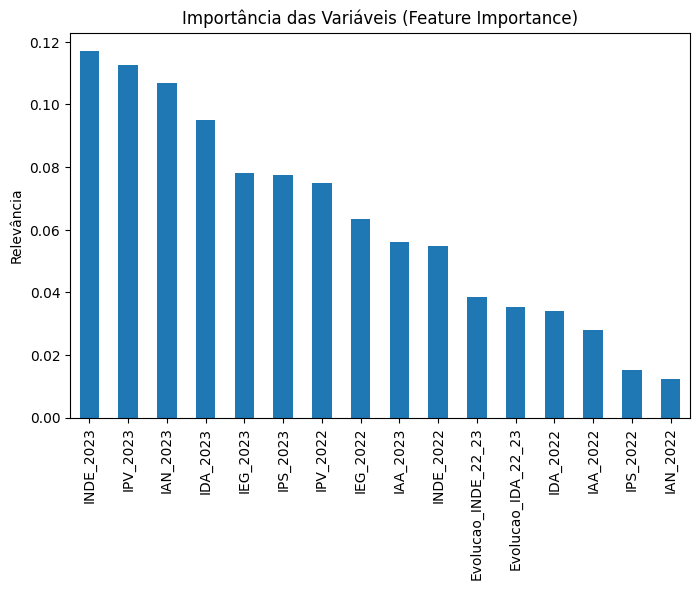

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Instanciando e Treinando o Modelo
# class_weight='balanced' ajuda o algoritmo a dar a devida atenção caso haja poucos alunos em risco comparado aos que estão bem
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo_rf.fit(X_train, y_train)

# 2. Fazendo Previsões na base de Teste (a nossa "prova cega")
y_pred = modelo_rf.predict(X_test)

# 3. Avaliando os Resultados
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred))

# 4. Exibindo a Matriz de Confusão de forma visual
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sem Risco (0)', 'Em Risco (1)'], 
            yticklabels=['Sem Risco (0)', 'Em Risco (1)'])
plt.title('Matriz de Confusão')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

# 5. Identificando as variáveis mais importantes para o modelo
importancias = pd.Series(modelo_rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
importancias.plot(kind='bar')
plt.title('Importância das Variáveis (Feature Importance)')
plt.ylabel('Relevância')
plt.show()

In [7]:
import joblib
import os

# Garantindo que a pasta models exista
# Como o notebook está dentro da pasta 'notebooks', usamos '../' para voltar uma pasta e entrar em 'models'
os.makedirs('../models', exist_ok=True)

# Salvando o modelo treinado em um arquivo .pkl
joblib.dump(modelo_rf, '../models/modelo_risco_defasagem.pkl')

print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!
